In [1]:
# ==========================================
# 1. IMPORT REQUIRED LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

import pickle


ModuleNotFoundError: No module named 'pandas'

In [ ]:
# ==========================================
# 2. LOAD DATASET
# ==========================================

df = pd.read_csv('../dataset/cleaned_animal_disease_prediction.csv')

# View data
df.head()


,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction
0,Dog,Labrador,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,3 days,...,No,No,No,No,No,No,No,39.5°C,120,Parvovirus
1,Cat,Siamese,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,1 week,...,No,Yes,No,No,No,Yes,Yes,38.9°C,150,Upper Respiratory Infection
2,Cow,Holstein,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,5 days,...,No,Yes,Yes,No,No,Yes,No,40.1°C,90,Foot and Mouth Disease
3,Dog,Beagle,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,2 days,...,Yes,No,No,No,No,No,No,39.2°C,130,Gastroenteritis
4,Cat,Persian,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,2 weeks,...,No,No,No,No,Yes,No,No,38.7°C,160,Fungal Infection


In [ ]:
# ==========================================
# 3. DATA UNDERSTANDING
# ==========================================

print("Shape of dataset:", df.shape)

# Info
df.info()

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Disease distribution
print("\nDisease Counts:\n", df['Disease_Prediction'].value_counts())


Shape of dataset: (431, 22)
<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Animal_Type         431 non-null    str    
 1   Breed               431 non-null    str    
 2   Age                 431 non-null    int64  
 3   Gender              431 non-null    str    
 4   Weight              431 non-null    float64
 5   Symptom_1           431 non-null    str    
 6   Symptom_2           431 non-null    str    
 7   Symptom_3           431 non-null    str    
 8   Symptom_4           431 non-null    str    
 9   Duration            431 non-null    str    
 10  Appetite_Loss       431 non-null    str    
 11  Vomiting            431 non-null    str    
 12  Diarrhea            431 non-null    str    
 13  Coughing            431 non-null    str    
 14  Labored_Breathing   431 non-null    str    
 15  Lameness            431 non-null    str 

In [ ]:
# ==========================================
# 4. DATA CLEANING
# ==========================================

# Remove missing values
df = df.dropna()


In [ ]:
# ==========================================
# 5. REMOVE RARE CLASSES
# ==========================================

counts = df['Disease_Prediction'].value_counts()

# Keep diseases with at least 10 samples
df = df[df['Disease_Prediction'].isin(counts[counts >= 10].index)]

print("Remaining diseases:", df['Disease_Prediction'].nunique())


Remaining diseases: 8


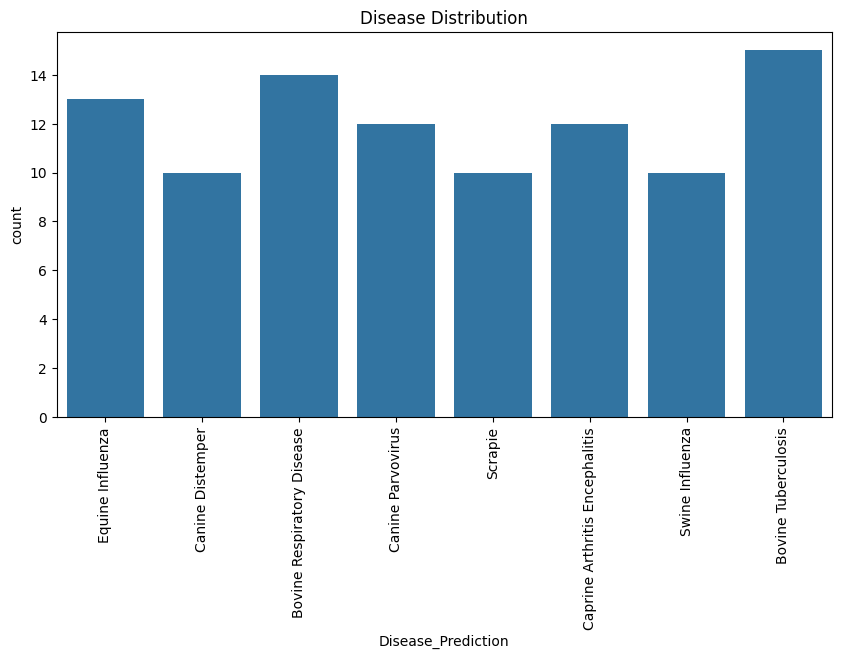

In [ ]:
# ==========================================
# 6. DATA VISUALIZATION
# ==========================================

plt.figure(figsize=(10,5))
sns.countplot(x='Disease_Prediction', data=df)
plt.xticks(rotation=90)
plt.title("Disease Distribution")
plt.show()


In [ ]:
# ==========================================
# 7. FEATURE SELECTION + FIX
# ==========================================

symptom_cols = [col for col in df.columns if 'Symptom' in col]

X = df[symptom_cols]

# 🔥 IMPORTANT FIX (convert text → number)
X = pd.get_dummies(X)

y = df['Disease_Prediction']



In [ ]:
# ==========================================
# 8. ENCODE TARGET
# ==========================================

le = LabelEncoder()
y = le.fit_transform(y)


In [ ]:
# ==========================================
# 9. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)


Decision Tree Accuracy: 0.5


In [ ]:
rf_model = RandomForestClassifier(n_estimators=200)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.5


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)


KNN Accuracy: 0.4


In [ ]:
# ==========================================
# 11. MODEL COMPARISON
# ==========================================

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'KNN'],
    'Accuracy': [dt_acc, rf_acc, knn_acc]
})

print(results)


           Model  Accuracy
0  Decision Tree       0.5
1  Random Forest       0.5
2            KNN       0.4


In [ ]:
# ==========================================
# 12. BEST MODEL
# ==========================================

best_model = rf_model   # Usually Random Forest is best


In [ ]:
# ==========================================
# 13. FINAL EVALUATION
# ==========================================

print("Final Model: Random Forest\n")
print(classification_report(y_test, rf_pred, zero_division=1))


Final Model: Random Forest

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.29      0.67      0.40         3
           2       0.33      0.50      0.40         2
           3       0.67      0.67      0.67         3
           4       1.00      1.00      1.00         2
           5       1.00      0.33      0.50         3
           6       1.00      0.50      0.67         2
           7       1.00      0.50      0.67         2

    accuracy                           0.50        20
   macro avg       0.66      0.52      0.54        20
weighted avg       0.63      0.50      0.51        20



In [ ]:
# ==========================================
# 14. SAVE MODEL
# ==========================================

pickle.dump(best_model, open('../backend/model.pkl', 'wb'))
pickle.dump(le, open('../backend/label_encoder.pkl', 'wb'))
pickle.dump(X.columns, open('../backend/columns.pkl', 'wb'))
